# 🦋 Benchmark de GANs Conditionnels — Classification de Papillons

**Référence :** StudioGAN: A Taxonomy and Benchmark of GANs for Image Synthesis (Kang et al., 2023)  
**Dataset :** [Butterfly Image Classification — Kaggle](https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification)  
**Architectures comparées :** CWGAN-GP · CDCGAN · CSNGAN  
**Métriques :** FID global · Intra-class FID · Precision & Recall

---
### Structure du notebook
1. Setup & installation
2. Chargement et prétraitement du dataset
3. Définition des architectures (backbone partagé)
4. Entraînement des trois modèles
5. Évaluation quantitative (FID, Intra-class FID, P&R)
6. Analyse qualitative (visualisations)
7. Tableau comparatif final

> ⚡ **Requis :** Activer le GPU dans Colab → `Exécution > Modifier le type d'exécution > GPU (T4)`

## 1. Setup & Installation

In [ ]:
# ── Vérification GPU ─────────────────────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '⚠️  Aucun GPU détecté — activer GPU dans Colab')

Wed May  6 19:59:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ── Installation des dépendances ─────────────────────────────────────────────
!pip install -q kaggle pytorch-fid clean-fid
print('✅ Dépendances installées')

✅ Dépendances installées


In [ ]:
# ── Connexion à Google Drive (sauvegarde des modèles) ────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/butterfly_gan_benchmark'
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/generated_images', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/results', exist_ok=True)
print(f'✅ Drive monté → {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive monté → /content/drive/MyDrive/butterfly_gan_benchmark


In [ ]:
# ── Configuration Kaggle API ─────────────────────────────────────────────────
# Option A : upload manuel du fichier kaggle.json
from google.colab import files
print('📂 Uploadez votre fichier kaggle.json (depuis kaggle.com > Account > API)')
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print('✅ Kaggle API configurée')

📂 Uploadez votre fichier kaggle.json (depuis kaggle.com > Account > API)


Saving kaggle.json to kaggle (1).json
✅ Kaggle API configurée


In [ ]:
# ── Téléchargement du dataset ────────────────────────────────────────────────
!kaggle datasets download -d phucthaiv02/butterfly-image-classification -p /content/data --unzip
print('✅ Dataset téléchargé')

# Afficher la structure
!find /content/data -maxdepth 2 -type d | head -30

Dataset URL: https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification
License(s): CC0-1.0
100% 226M/226M [00:11<00:00, 20.2MB/s]

✅ Dataset téléchargé
/content/data
/content/data/train
/content/data/test


In [ ]:
# ── Imports généraux ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, utils
from torchvision.datasets import ImageFolder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
import json, time, shutil
from tqdm.auto import tqdm

# ── Config globale ────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 64          # résolution des images générées
LATENT_DIM  = 128         # dimension du vecteur de bruit z
N_CLASSES   = None        # sera défini après chargement du dataset
EMBED_DIM   = 64          # dimension de l'embedding de classe
BATCH_SIZE  = 64
N_EPOCHS    = 100         # à augmenter pour de meilleurs résultats
LR_G        = 1e-4        # learning rate générateur
LR_D        = 1e-4        # learning rate discriminateur/critique
N_CRITIC    = 5           # steps critique par step générateur (WGAN)
GP_LAMBDA   = 10          # poids du gradient penalty
SAVE_EVERY  = 20          # sauvegarder checkpoint toutes les N epochs
N_EVAL_IMG  = 5000        # images générées pour le calcul FID
TOP_K       = None          # nombre d'espèces à conserver (None = toutes)
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'✅ Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 2. Chargement et Prétraitement du Dataset

In [ ]:
# ── Détection automatique du chemin des données ───────────────────────────────
import pandas as pd
from pathlib import Path

# Chemins possibles pour les CSV et les images
CSV_CANDIDATES = [
    ('/content/data/Training_set.csv', '/content/data/train'),
    ('/content/data/training.csv',     '/content/data/train'),
    ('/content/data/Training_set.csv', '/content/data'),
    ('/content/data/training.csv',     '/content/data'),
]

IMG_ROOT  = None
df_train  = None

for csv_path, img_dir in CSV_CANDIDATES:
    if Path(csv_path).exists():
        df_train = pd.read_csv(csv_path)
        IMG_ROOT = img_dir
        print(f'✅ CSV trouvé       : {csv_path}')
        print(f'   Dossier images   : {img_dir}')
        break

if df_train is None:
    print('⚠️  CSV non trouvé. Fichiers disponibles :')
    !find /content/data -name "*.csv" | head -20
    csv_path = input('Chemin du CSV d\'entraînement : ')
    img_dir  = input('Chemin du dossier images     : ')
    df_train = pd.read_csv(csv_path)
    IMG_ROOT = img_dir

# Normalisation des noms de colonnes (minuscules, strip)
df_train.columns = df_train.columns.str.strip().str.lower()
print(f'\nColonnes détectées : {df_train.columns.tolist()}')
print(df_train.head(3).to_string(index=False))

# Charger le CSV de test si disponible
TEST_CSV_CANDIDATES = ['/content/data/Testing_set.csv', '/content/data/testing.csv']
df_test = None
for p in TEST_CSV_CANDIDATES:
    if Path(p).exists():
        df_test = pd.read_csv(p)
        df_test.columns = df_test.columns.str.strip().str.lower()
        print(f'\n✅ CSV test trouvé : {p}  ({len(df_test)} images)')
        break

# ── Extraction des classes depuis le CSV ──────────────────────────────────────
all_classes = sorted(df_train['label'].dropna().unique().tolist())
N_CLASSES   = len(all_classes)
print(f'\n✅ {N_CLASSES} espèces trouvées dans le CSV')
print(f'   Exemples : {all_classes[:5]}')

✅ CSV trouvé       : /content/data/Training_set.csv
   Dossier images   : /content/data/train

Colonnes détectées : ['filename', 'label']
   filename            label
Image_1.jpg SOUTHERN DOGFACE
Image_2.jpg           ADONIS
Image_3.jpg   BROWN SIPROETA

✅ CSV test trouvé : /content/data/Testing_set.csv  (2786 images)

✅ 75 espèces trouvées dans le CSV
   Exemples : ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO']


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])


class ButterflyDataset(Dataset):
    """Dataset piloté par CSV (filename → label)."""
    def __init__(self, df, img_root, class_to_idx, transform=None):
        self.img_root    = Path(img_root)
        self.transform   = transform
        self.class_to_idx = class_to_idx
        # Filtrer sur les classes sélectionnées
        self.samples = [
            (row['filename'], class_to_idx[row['label']])
            for _, row in df.iterrows()
            if row['label'] in class_to_idx
        ]
        print(f'   → {len(self.samples)} images chargées')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        img = Image.open(self.img_root / filename).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


# Sélection top-K espèces (par fréquence dans le CSV)
top_classes = (df_train['label'].value_counts()
                                .head(TOP_K if TOP_K else N_CLASSES)
                                .index.tolist())
N_CLASSES    = len(top_classes)
class_to_idx = {cls: i for i, cls in enumerate(top_classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

print(f'✅ {N_CLASSES} espèces sélectionnées')

dataset    = ButterflyDataset(df_train, IMG_ROOT, class_to_idx, train_transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=True, drop_last=True)
print(f'✅ DataLoader prêt — {len(dataloader)} batches/epoch')

✅ 75 espèces sélectionnées
   → 6499 images chargées
✅ DataLoader prêt — 101 batches/epoch


In [ ]:
# ── Statistiques du dataset ───────────────────────────────────────────────────
df_stats = (df_train[df_train['label'].isin(class_to_idx)]
            .groupby('label')
            .size()
            .reset_index(name='nb_images')
            .rename(columns={'label': 'espece'})
            .sort_values('nb_images', ascending=False)
            .reset_index(drop=True))

print(f'📊 Statistiques du dataset')
print(f'   Total images      : {df_stats.nb_images.sum()}')
print(f'   Espèces           : {len(df_stats)}')
print(f'   Min images/espèce : {df_stats.nb_images.min()}')
print(f'   Max images/espèce : {df_stats.nb_images.max()}')
print(f'   Moyenne           : {df_stats.nb_images.mean():.0f}')
print()
print(df_stats.head(20).to_string(index=False))

📊 Statistiques du dataset
   Total images      : 6499
   Espèces           : 75
   Min images/espèce : 71
   Max images/espèce : 131
   Moyenne           : 87

                  espece  nb_images
          MOURNING CLOAK        131
           SLEEPY ORANGE        107
                   ATALA        100
          BROWN SIPROETA         99
                 CRECENT         97
BANDED ORANGE HELICONIAN         97
          SCARCE SWALLOW         97
              ORANGE TIP         96
             RED CRACKER         96
  MILBERTS TORTOISESHELL         96
         IPHICLUS SISTER         95
      CHECQUERED SKIPPER         95
      EASTERN PINE ELFIN         95
           DANAID EGGFLY         94
               GREAT JAY         94
             COPPER TAIL         94
               CLEOPATRA         93
            EASTERN COMA         93
    EASTERN DAPPLE WHITE         92
         CLOUDED SULPHUR         92


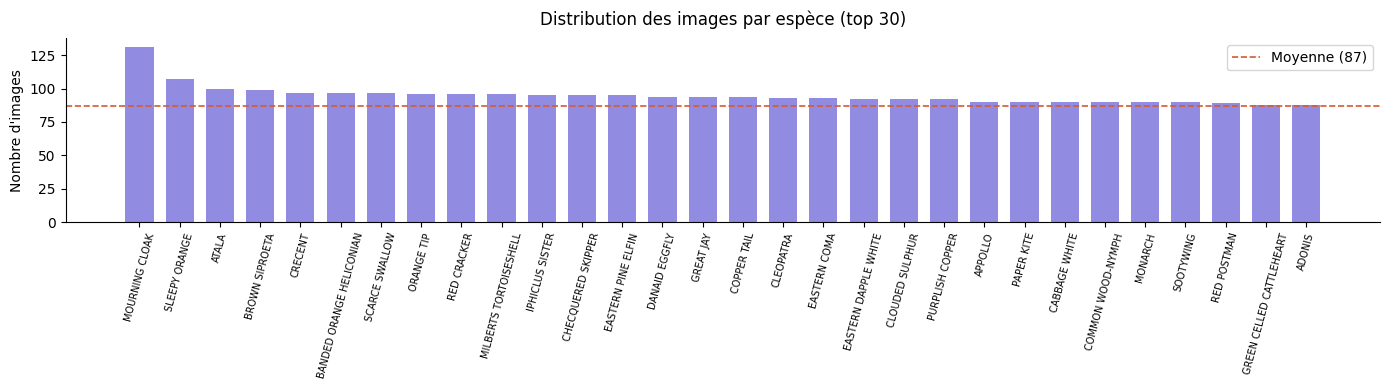

In [ ]:
# ── Visualisation distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
top = df_stats.head(30)
bars = ax.bar(top['espece'], top['nb_images'], color='#7F77DD', alpha=0.85, width=0.7)
ax.axhline(df_stats.nb_images.mean(), color='#D85A30', ls='--', lw=1.2, label=f'Moyenne ({df_stats.nb_images.mean():.0f})')
ax.set_title('Distribution des images par espèce (top 30)', fontsize=12, pad=10)
ax.set_ylabel('Nombre d\'images')
ax.tick_params(axis='x', rotation=75, labelsize=7)
ax.spines[['top','right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/results/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Sélection des espèces (top-k pour équilibrer) ─────────────────────────────
if TOP_K is not None:
    selected_classes = df_stats.head(TOP_K)['espece'].tolist()
    print(f'✅ {TOP_K} espèces sélectionnées (les plus représentées) :')
else:
    selected_classes = df_stats['espece'].tolist()
    print(f'✅ Toutes les {len(selected_classes)} espèces sélectionnées')

N_CLASSES = len(selected_classes)
class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
print(f'   N_CLASSES = {N_CLASSES}')
for i, c in idx_to_class.items():
    print(f'   [{i:2d}] {c}')

✅ Toutes les 75 espèces sélectionnées
   N_CLASSES = 75
   [ 0] MOURNING CLOAK
   [ 1] SLEEPY ORANGE
   [ 2] ATALA
   [ 3] BROWN SIPROETA
   [ 4] CRECENT
   [ 5] BANDED ORANGE HELICONIAN
   [ 6] SCARCE SWALLOW
   [ 7] ORANGE TIP
   [ 8] RED CRACKER
   [ 9] MILBERTS TORTOISESHELL
   [10] IPHICLUS SISTER
   [11] CHECQUERED SKIPPER
   [12] EASTERN PINE ELFIN
   [13] DANAID EGGFLY
   [14] GREAT JAY
   [15] COPPER TAIL
   [16] CLEOPATRA
   [17] EASTERN COMA
   [18] EASTERN DAPPLE WHITE
   [19] CLOUDED SULPHUR
   [20] PURPLISH COPPER
   [21] APPOLLO
   [22] PAPER KITE
   [23] CABBAGE WHITE
   [24] COMMON WOOD-NYMPH
   [25] MONARCH
   [26] SOOTYWING
   [27] RED POSTMAN
   [28] GREEN CELLED CATTLEHEART
   [29] ADONIS
   [30] CLODIUS PARNASSIAN
   [31] SOUTHERN DOGFACE
   [32] MANGROVE SKIPPER
   [33] STRAITED QUEEN
   [34] ORANGE OAKLEAF
   [35] COMMON BANDED AWL
   [36] BLUE SPOTTED CROW
   [37] RED SPOTTED PURPLE
   [38] GREY HAIRSTREAK
   [39] PINE WHITE
   [40] MESTRA
   [41] AN 88
   [42]

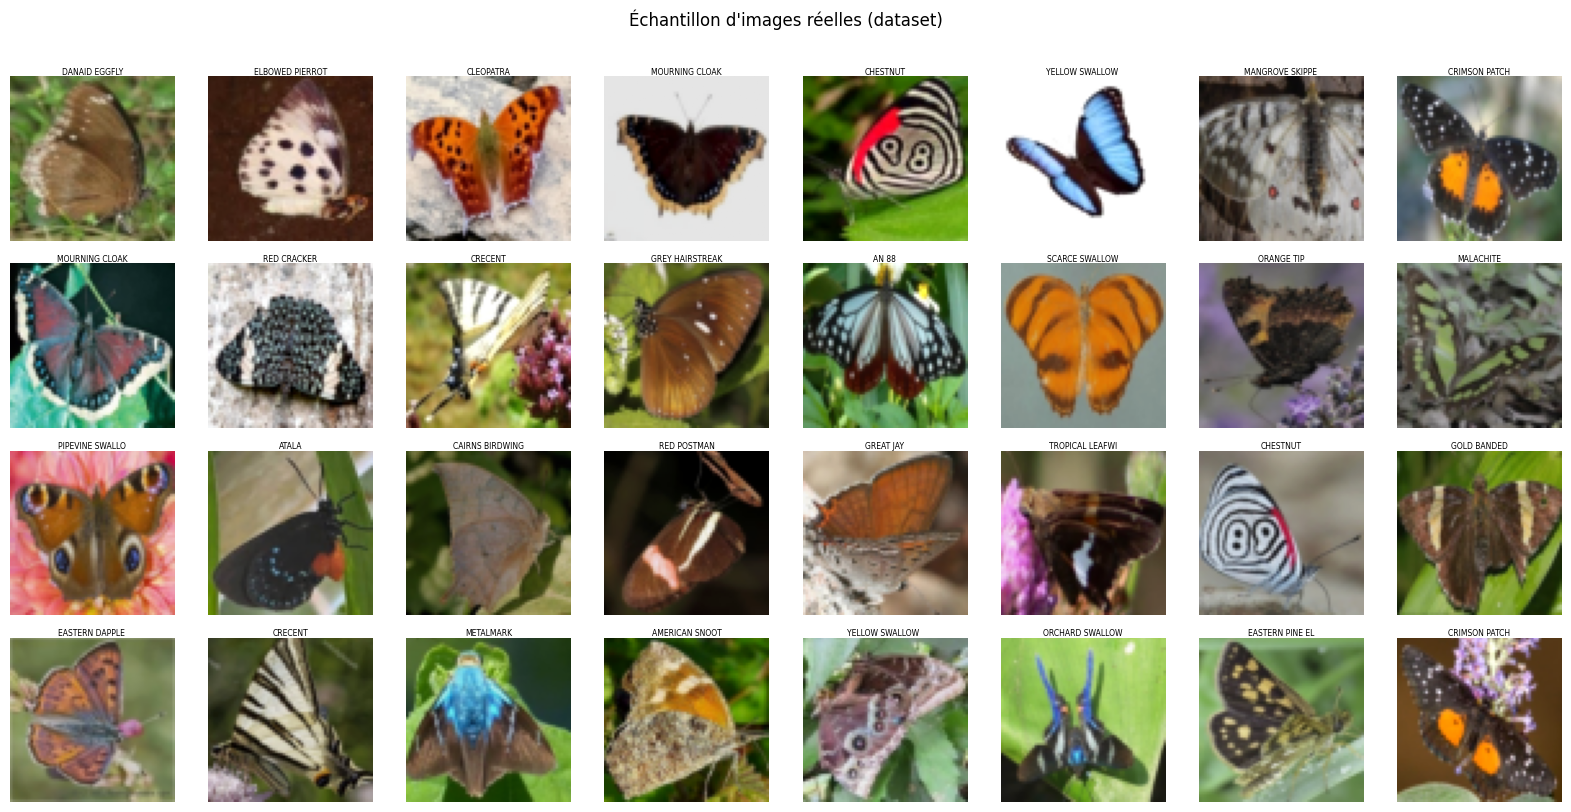

In [ ]:
# ── Visualisation d'un batch réel ─────────────────────────────────────────────
real_batch, real_labels = next(iter(dataloader))
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < 32:
        img = real_batch[i].permute(1,2,0).numpy() * 0.5 + 0.5
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(idx_to_class[real_labels[i].item()].replace('_',' ')[:15],
                     fontsize=5.5, pad=2)
    ax.axis('off')
plt.suptitle('Échantillon d\'images réelles (dataset)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/results/real_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Architectures GAN (Backbone Partagé)

Les trois architectures partagent le **même backbone convolutionnel** (G et D/Critique).  
Seuls varient : la **loss adversariale**, la **régularisation** et le **mécanisme de conditioning**.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCS DE CONSTRUCTION COMMUNS
# ══════════════════════════════════════════════════════════════════════════════

def weights_init(m):
    """Initialisation des poids selon DCGAN (Radford et al., 2015)."""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class ConvBlock(nn.Module):
    """Bloc convolutionnel avec BN + LeakyReLU (discriminateur)."""
    def __init__(self, in_ch, out_ch, stride=2, use_bn=True, use_sn=False):
        super().__init__()
        conv = nn.Conv2d(in_ch, out_ch, 4, stride, 1, bias=not use_bn)
        if use_sn:
            conv = nn.utils.spectral_norm(conv)
        layers = [conv]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class TransposedConvBlock(nn.Module):
    """Bloc de déconvolution avec BN + ReLU (générateur)."""
    def __init__(self, in_ch, out_ch, last=False):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        if not last:
            layers += [nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        else:
            layers.append(nn.Tanh())  # sortie dans [-1, 1]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# GÉNÉRATEUR CONDITIONNEL (partagé par les 3 architectures)
# z (latent) + label embedding → image 64×64
# ══════════════════════════════════════════════════════════════════════════════

class ConditionalGenerator(nn.Module):
    """
    Générateur DCGAN conditionnel.
    Architecture : z + embed(label) → Linear → reshape → 4 TransposedConvBlocks → 64×64 RGB
    """
    def __init__(self, latent_dim, n_classes, embed_dim, ngf=64):
        super().__init__()
        self.label_embed = nn.Embedding(n_classes, embed_dim)
        input_dim = latent_dim + embed_dim

        # Projection vers feature map 4×4
        self.proj = nn.Sequential(
            nn.Linear(input_dim, ngf * 8 * 4 * 4, bias=False),
        )
        self.ngf = ngf

        # 4×4 → 8×8 → 16×16 → 32×32 → 64×64
        self.deconv = nn.Sequential(
            TransposedConvBlock(ngf * 8, ngf * 4),   # 4→8
            TransposedConvBlock(ngf * 4, ngf * 2),   # 8→16
            TransposedConvBlock(ngf * 2, ngf),        # 16→32
            TransposedConvBlock(ngf, 3, last=True),   # 32→64, Tanh
        )
        self._init_weights()  # ← appel corrigé

    def _init_weights(self):
        """Initialisation récursive : descend dans tous les sous-modules."""
        for m in self.modules():  # .modules() parcourt TOUS les sous-modules récursivement
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias.data, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight.data, 1.0, 0.02)
                nn.init.constant_(m.bias.data, 0)

    def forward(self, z, labels):
        emb = self.label_embed(labels)           # (B, embed_dim)
        x = torch.cat([z, emb], dim=1)           # (B, latent+embed)
        x = self.proj(x)                          # (B, ngf*8*16)
        x = x.view(-1, self.ngf * 8, 4, 4)       # (B, ngf*8, 4, 4)
        return self.deconv(x)                     # (B, 3, 64, 64)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test rapide
_G = ConditionalGenerator(LATENT_DIM, N_CLASSES, EMBED_DIM)
_z = torch.randn(4, LATENT_DIM)
_l = torch.randint(0, N_CLASSES, (4,))
print(f'✅ Générateur — output shape : {_G(_z, _l).shape}')
print(f'   Paramètres : {_G.count_params():,}')
del _G, _z, _l

✅ Générateur — output shape : torch.Size([4, 3, 64, 64])
   Paramètres : 4,334,144


In [ ]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, n_classes, embed_dim, ndf=64, use_sn=False, use_bn=True):
        super().__init__()
        self.use_sn = use_sn

        def _conv(in_ch, out_ch, stride=2, bn=use_bn):
            return ConvBlock(in_ch, out_ch, stride=stride, use_bn=bn, use_sn=use_sn)

        self.features = nn.Sequential(
            _conv(3,       ndf,     bn=False),
            _conv(ndf,     ndf * 2),
            _conv(ndf * 2, ndf * 4),
            _conv(ndf * 4, ndf * 8),
        )

        feat_dim = ndf * 8 * 4 * 4

        linear = nn.Linear(feat_dim, 1)
        if use_sn:
            linear = nn.utils.spectral_norm(linear)
        self.linear = linear

        self.embed = nn.Embedding(n_classes, feat_dim)
        if use_sn:
            self.embed = nn.utils.spectral_norm(self.embed)

        self._init_weights()  # ← corrigé

    def _init_weights(self):
        """Initialisation récursive sur les primitives PyTorch uniquement."""
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias.data, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight.data, 1.0, 0.02)
                nn.init.constant_(m.bias.data, 0)

    def forward(self, x, labels):
        phi = self.features(x)
        phi = phi.view(phi.size(0), -1)
        out = self.linear(phi)
        emb = self.embed(labels)
        proj = (phi * emb).sum(dim=1, keepdim=True)
        return (out + proj).squeeze(1)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test
_D = ConditionalDiscriminator(N_CLASSES, EMBED_DIM)
_x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE)
_l = torch.randint(0, N_CLASSES, (4,))
print(f'✅ Discriminateur — output shape : {_D(_x, _l).shape}')
print(f'   Paramètres : {_D.count_params():,}')
del _D, _x, _l

✅ Discriminateur — output shape : torch.Size([4])
   Paramètres : 3,380,033


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FONCTIONS DE LOSS
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. BCE Loss (CDCGAN) ──────────────────────────────────────────────────────
def dcgan_loss_D(real_logits, fake_logits):
    """Loss discriminateur BCE standard."""
    real_loss = F.binary_cross_entropy_with_logits(real_logits, torch.ones_like(real_logits))
    fake_loss = F.binary_cross_entropy_with_logits(fake_logits, torch.zeros_like(fake_logits))
    return (real_loss + fake_loss) / 2

def dcgan_loss_G(fake_logits):
    """Loss générateur BCE (non-saturating)."""
    return F.binary_cross_entropy_with_logits(fake_logits, torch.ones_like(fake_logits))


# ── 2. Wasserstein Loss (CWGAN-GP) ────────────────────────────────────────────
def wgan_loss_D(real_scores, fake_scores):
    """Loss critique Wasserstein : maximise E[D(real)] - E[D(fake)]."""
    return fake_scores.mean() - real_scores.mean()

def wgan_loss_G(fake_scores):
    """Loss générateur Wasserstein : minimise -E[D(fake)]."""
    return -fake_scores.mean()

def gradient_penalty(critic, real_imgs, fake_imgs, real_labels, device):
    """
    Gradient Penalty (Gulrajani et al., 2017).
    Pénalise le gradient du critique interpolé entre réel et faux.
    """
    alpha = torch.rand(B, 1, 1, 1, device=device)

    interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs

    # interpolation des labels (option simple : choisir real ou fake)
    labels = real_labels  # ou fake_labels, mais cohérent avec usage

    interpolated.requires_grad_(True)

    d_interp = critic(interpolated, labels)
    grads = torch.autograd.grad(
        outputs=d_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(B, -1)
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp


# ── 3. Hinge Loss (CSNGAN) ────────────────────────────────────────────────────
def hinge_loss_D(real_logits, fake_logits):
    """Loss discriminateur Hinge."""
    real_loss = F.relu(1.0 - real_logits).mean()
    fake_loss = F.relu(1.0 + fake_logits).mean()
    return real_loss + fake_loss

def hinge_loss_G(fake_logits):
    """Loss générateur Hinge."""
    return -fake_logits.mean()


print('✅ Fonctions de loss définies (BCE / Wasserstein+GP / Hinge)')

✅ Fonctions de loss définies (BCE / Wasserstein+GP / Hinge)


## 4. Entraînement

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# UTILITAIRES D'ENTRAÎNEMENT
# ══════════════════════════════════════════════════════════════════════════════

def save_checkpoint(arch_name, epoch, G, D, opt_G, opt_D, history):
    """Sauvegarde un checkpoint complet sur Google Drive."""
    ckpt_path = f'{DRIVE_DIR}/checkpoints/{arch_name}_epoch{epoch:04d}.pt'
    torch.save({
        'epoch': epoch,
        'arch': arch_name,
        'G_state': G.state_dict(),
        'D_state': D.state_dict(),
        'opt_G_state': opt_G.state_dict(),
        'opt_D_state': opt_D.state_dict(),
        'history': history,
        'n_classes': N_CLASSES,
        'class_to_idx': class_to_idx,
        'config': {
            'latent_dim': LATENT_DIM,
            'embed_dim': EMBED_DIM,
            'img_size': IMG_SIZE,
        }
    }, ckpt_path)
    # Garder aussi le dernier checkpoint avec un nom fixe
    shutil.copy(ckpt_path, f'{DRIVE_DIR}/checkpoints/{arch_name}_latest.pt')
    return ckpt_path


def load_checkpoint(arch_name, G, D, opt_G, opt_D):
    """Charge le dernier checkpoint si disponible."""
    path = f'{DRIVE_DIR}/checkpoints/{arch_name}_latest.pt'
    if not Path(path).exists():
        print(f'   Aucun checkpoint trouvé pour {arch_name}')
        return 0, []
    ckpt = torch.load(path, map_location=DEVICE)
    G.load_state_dict(ckpt['G_state'])
    D.load_state_dict(ckpt['D_state'])
    opt_G.load_state_dict(ckpt['opt_G_state'])
    opt_D.load_state_dict(ckpt['opt_D_state'])
    print(f'   ✅ Checkpoint chargé : epoch {ckpt["epoch"]}')
    return ckpt['epoch'], ckpt.get('history', [])


def generate_fixed_grid(G, arch_name, epoch, n_per_class=4):
    """Génère une grille d'images fixes (même z) pour suivre la progression."""
    G.eval()
    with torch.no_grad():
        all_imgs = []
        for cls_idx in range(min(N_CLASSES, 8)):
            z = torch.randn(n_per_class, LATENT_DIM, device=DEVICE)
            labels = torch.full((n_per_class,), cls_idx, dtype=torch.long, device=DEVICE)
            imgs = G(z, labels).cpu()
            all_imgs.append(imgs)
        grid_imgs = torch.cat(all_imgs, dim=0)
        grid = utils.make_grid(grid_imgs * 0.5 + 0.5, nrow=n_per_class, padding=2)
        fig, ax = plt.subplots(figsize=(10, min(N_CLASSES, 8) * 1.4))
        ax.imshow(grid.permute(1, 2, 0).numpy())
        ax.set_title(f'{arch_name} — Epoch {epoch}', fontsize=11)
        ax.axis('off')
        path = f'{DRIVE_DIR}/generated_images/{arch_name}_epoch{epoch:04d}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()
    G.train()


def plot_losses(history, arch_name):
    """Affiche les courbes de loss G et D."""
    epochs = [h['epoch'] for h in history]
    g_loss = [h['g_loss'] for h in history]
    d_loss = [h['d_loss'] for h in history]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
    ax1.plot(epochs, g_loss, '#7F77DD', lw=1.5)
    ax1.set_title(f'{arch_name} — Loss Générateur')
    ax1.set_xlabel('Epoch')
    ax1.spines[['top','right']].set_visible(False)
    ax2.plot(epochs, d_loss, '#D85A30', lw=1.5)
    ax2.set_title(f'{arch_name} — Loss Discriminateur')
    ax2.set_xlabel('Epoch')
    ax2.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_DIR}/results/{arch_name}_losses.png', dpi=120, bbox_inches='tight')
    plt.show()


print('✅ Utilitaires d\'entraînement prêts')

✅ Utilitaires d'entraînement prêts


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BOUCLE D'ENTRAÎNEMENT GÉNÉRIQUE
# ══════════════════════════════════════════════════════════════════════════════

def train_gan(arch_name, G, D, opt_G, opt_D,
              dataloader, n_epochs, device,
              mode='dcgan',          # 'dcgan' | 'wgan-gp' | 'sngan'
              n_critic=1,
              gp_lambda=10,
              resume=True):
    """
    Boucle d'entraînement commune aux trois architectures.

    Args:
        mode : contrôle la loss et le scheduling du critique
               'dcgan'  → BCE loss, 1 step D / 1 step G
               'wgan-gp'→ Wasserstein + GP, n_critic steps D / 1 step G
               'sngan'  → Hinge loss, 1 step D / 1 step G
    """
    G.to(device)
    D.to(device)
    G.train()
    D.train()

    # Reprise depuis checkpoint
    start_epoch = 0
    history = []
    if resume:
        start_epoch, history = load_checkpoint(arch_name, G, D, opt_G, opt_D)

    print(f'\n{'='*60}')
    print(f'  Entraînement : {arch_name} ({mode.upper()})')
    print(f'  Epochs       : {start_epoch+1} → {n_epochs}')
    print(f'  Batches/ep   : {len(dataloader)}')
    print(f'{'='*60}')

    for epoch in range(start_epoch + 1, n_epochs + 1):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        t0 = time.time()

        pbar = tqdm(dataloader, desc=f'Ep {epoch}/{n_epochs}', leave=False)
        step = 0

        for real_imgs, real_labels in pbar:
            B = real_imgs.size(0)
            real_imgs   = real_imgs.to(device)
            real_labels = real_labels.to(device)

            # ── Entraînement Discriminateur / Critique ────────────────────────
            n_d_steps = n_critic if mode == 'wgan-gp' else 1

            for _ in range(n_d_steps):
                opt_D.zero_grad()
                z = torch.randn(B, LATENT_DIM, device=device)
                fake_labels = torch.randint(0, N_CLASSES, (B,), device=device)
                with torch.no_grad():
                    fake_imgs = G(z, fake_labels)

                real_logits = D(real_imgs, real_labels)
                fake_logits = D(fake_imgs.detach(), fake_labels)

                if mode == 'dcgan':
                    d_loss = dcgan_loss_D(real_logits, fake_logits)
                elif mode == 'wgan-gp':
                    d_loss = wgan_loss_D(real_logits, fake_logits)
                    gp = gradient_penalty(D, real_imgs, fake_imgs.detach(),
                                          real_labels, device)
                    d_loss = d_loss + gp_lambda * gp
                elif mode == 'sngan':
                    d_loss = hinge_loss_D(real_logits, fake_logits)

                d_loss.backward()
                opt_D.step()

            epoch_d_loss += d_loss.item()

            # ── Entraînement Générateur ───────────────────────────────────────
            opt_G.zero_grad()
            z = torch.randn(B, LATENT_DIM, device=device)
            fake_labels = torch.randint(0, N_CLASSES, (B,), device=device)
            fake_imgs = G(z, fake_labels)
            fake_logits = D(fake_imgs, fake_labels)

            if mode == 'dcgan':
                g_loss = dcgan_loss_G(fake_logits)
            elif mode == 'wgan-gp':
                g_loss = wgan_loss_G(fake_logits)
            elif mode == 'sngan':
                g_loss = hinge_loss_G(fake_logits)

            g_loss.backward()
            opt_G.step()
            epoch_g_loss += g_loss.item()

            pbar.set_postfix({'D': f'{d_loss.item():.3f}', 'G': f'{g_loss.item():.3f}'})
            step += 1

        # ── Fin d'epoch ───────────────────────────────────────────────────────
        avg_g = epoch_g_loss / len(dataloader)
        avg_d = epoch_d_loss / len(dataloader)
        elapsed = time.time() - t0
        history.append({'epoch': epoch, 'g_loss': avg_g, 'd_loss': avg_d,
                         'time': elapsed})

        print(f'Ep {epoch:4d}/{n_epochs} | G: {avg_g:7.4f} | D: {avg_d:7.4f} '
              f'| {elapsed:.1f}s')

        # Sauvegarde périodique sur Drive
        if epoch % SAVE_EVERY == 0 or epoch == n_epochs:
            path = save_checkpoint(arch_name, epoch, G, D, opt_G, opt_D, history)
            print(f'   💾 Checkpoint → {path}')
            generate_fixed_grid(G, arch_name, epoch)

    plot_losses(history, arch_name)
    return G, D, history


print('✅ Boucle d\'entraînement générique prête')

✅ Boucle d'entraînement générique prête


── CDCGAN (Conditional DCGAN) ──
   ✅ Checkpoint chargé : epoch 100

  Entraînement : CDCGAN (DCGAN)
  Epochs       : 101 → 100
  Batches/ep   : 101


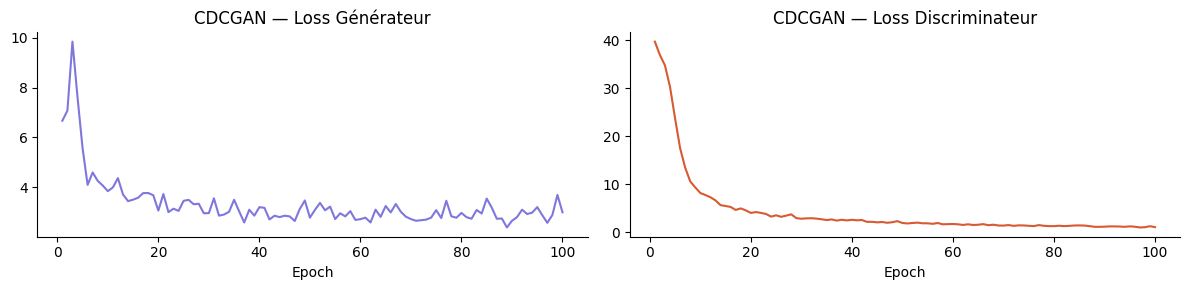

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE 1 : CDCGAN (baseline)
# Loss BCE, BN dans le discriminateur
# ══════════════════════════════════════════════════════════════════════════════

print('── CDCGAN (Conditional DCGAN) ──')
G_dcgan = ConditionalGenerator(LATENT_DIM, N_CLASSES, EMBED_DIM).to(DEVICE)
D_dcgan = ConditionalDiscriminator(N_CLASSES, EMBED_DIM,
                                    use_sn=False, use_bn=True).to(DEVICE)

opt_G_dcgan = optim.Adam(G_dcgan.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_D_dcgan = optim.Adam(D_dcgan.parameters(), lr=LR_D, betas=(0.5, 0.999))

G_dcgan, D_dcgan, hist_dcgan = train_gan(
    arch_name  = 'CDCGAN',
    G          = G_dcgan,
    D          = D_dcgan,
    opt_G      = opt_G_dcgan,
    opt_D      = opt_D_dcgan,
    dataloader = dataloader,
    n_epochs   = N_EPOCHS,
    device     = DEVICE,
    mode       = 'dcgan',
    resume     = True
)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE 2 : CWGAN-GP (référence)
# Loss Wasserstein + Gradient Penalty, PAS de BN dans le critique
# ══════════════════════════════════════════════════════════════════════════════

print('── CWGAN-GP (Conditional Wasserstein GAN + GP) ──')
G_wgan = ConditionalGenerator(LATENT_DIM, N_CLASSES, EMBED_DIM).to(DEVICE)
# Pas de BN dans le critique WGAN (recommandation Gulrajani et al.)
D_wgan = ConditionalDiscriminator(N_CLASSES, EMBED_DIM,
                                   use_sn=False, use_bn=False).to(DEVICE)

# WGAN utilise RMSprop ou Adam avec betas=(0, 0.9)
opt_G_wgan = optim.Adam(G_wgan.parameters(), lr=LR_G, betas=(0.0, 0.9))
opt_D_wgan = optim.Adam(D_wgan.parameters(), lr=LR_D, betas=(0.0, 0.9))

G_wgan, D_wgan, hist_wgan = train_gan(
    arch_name  = 'CWGAN-GP',
    G          = G_wgan,
    D          = D_wgan,
    opt_G      = opt_G_wgan,
    opt_D      = opt_D_wgan,
    dataloader = dataloader,
    n_epochs   = N_EPOCHS,
    device     = DEVICE,
    mode       = 'wgan-gp',
    n_critic   = N_CRITIC,
    gp_lambda  = GP_LAMBDA,
    resume     = True
)

── CWGAN-GP (Conditional Wasserstein GAN + GP) ──
   Aucun checkpoint trouvé pour CWGAN-GP

  Entraînement : CWGAN-GP (WGAN-GP)
  Epochs       : 1 → 100
  Batches/ep   : 101


Ep 1/100:   0%|          | 0/101 [00:00<?, ?it/s]

NameError: name 'B' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE 3 : CSNGAN (Spectral Normalization)
# Loss Hinge, Spectral Norm sur toutes les couches du discriminateur
# ══════════════════════════════════════════════════════════════════════════════

print('── CSNGAN (Conditional Spectral Normalization GAN) ──')
G_sngan = ConditionalGenerator(LATENT_DIM, N_CLASSES, EMBED_DIM).to(DEVICE)
# Spectral Norm activée, pas de BN (SN et BN incompatibles en pratique)
D_sngan = ConditionalDiscriminator(N_CLASSES, EMBED_DIM,
                                    use_sn=True, use_bn=False).to(DEVICE)

opt_G_sngan = optim.Adam(G_sngan.parameters(), lr=2e-4, betas=(0.0, 0.9))
opt_D_sngan = optim.Adam(D_sngan.parameters(), lr=1e-4, betas=(0.0, 0.9))

G_sngan, D_sngan, hist_sngan = train_gan(
    arch_name  = 'CSNGAN',
    G          = G_sngan,
    D          = D_sngan,
    opt_G      = opt_G_sngan,
    opt_D      = opt_D_sngan,
    dataloader = dataloader,
    n_epochs   = N_EPOCHS,
    device     = DEVICE,
    mode       = 'sngan',
    resume     = True
)

── CSNGAN (Conditional Spectral Normalization GAN) ──
   Aucun checkpoint trouvé pour CSNGAN

  Entraînement : CSNGAN (SNGAN)
  Epochs       : 1 → 100
  Batches/ep   : 101


Ep 1/100:   0%|          | 0/101 [00:00<?, ?it/s]

Ep    1/100 | G:  0.5500 | D:  0.9908 | 23.0s


Ep 2/100:   0%|          | 0/101 [00:00<?, ?it/s]

Ep    2/100 | G:  0.4377 | D:  1.4908 | 22.2s


...

Ep    3/100 | G:  0.5535 | D:  1.8093 | 22.9s


Ep 4/100:   0%|          | 0/101 [00:00<?, ?it/s]

Ep    4/100 | G:  0.5298 | D:  1.9181 | 23.6s


Ep 5/100:   0%|          | 0/101 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Évaluation Quantitative

- **FID global** : distance entre la distribution de toutes les images réelles et celle de toutes les images générées
- **Intra-class FID** : FID calculé séparément par espèce (Section 7.6 StudioGAN) → mesure la fidélité au label de classe
- **Precision & Recall** : qualité et diversité des images générées

In [ ]:
# ── Génération des images pour évaluation FID ─────────────────────────────────
from torchvision.transforms.functional import to_pil_image

def generate_images_for_fid(G, arch_name, n_per_class=500, batch_size=64):
    """
    Génère n_per_class images par espèce et les sauvegarde.
    Retourne le chemin du dossier (structure class/img.png pour clean-fid).
    """
    out_dir = Path(f'/content/fid_gen/{arch_name}')
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True)

    G.eval()
    with torch.no_grad():
        for cls_idx in tqdm(range(N_CLASSES), desc=f'{arch_name} — génération'):
            cls_dir = out_dir / idx_to_class[cls_idx]
            cls_dir.mkdir()
            generated = 0
            while generated < n_per_class:
                bs = min(batch_size, n_per_class - generated)
                z = torch.randn(bs, LATENT_DIM, device=DEVICE)
                labels = torch.full((bs,), cls_idx, dtype=torch.long, device=DEVICE)
                imgs = G(z, labels).cpu()  # (bs, 3, 64, 64) dans [-1,1]
                imgs = (imgs * 0.5 + 0.5).clamp(0, 1)  # → [0,1]
                for i, img in enumerate(imgs):
                    to_pil_image(img).save(cls_dir / f'{generated+i:05d}.png')
                generated += bs
    G.train()
    print(f'✅ {arch_name} : {N_CLASSES * n_per_class} images générées → {out_dir}')
    return str(out_dir)


def save_real_images_for_fid(n_per_class=500):
    """Sauvegarde les images réelles (même format que les générées)."""
    out_dir = Path('/content/fid_real')
    if out_dir.exists():
        return str(out_dir)
    out_dir.mkdir(parents=True)
    ds = ButterflyDataset(DATA_ROOT, selected_classes, class_to_idx, eval_transform)
    # Grouper par classe
    by_class = {i: [] for i in range(N_CLASSES)}
    for img, label in tqdm(ds, desc='Sauvegarde images réelles'):
        if len(by_class[label]) < n_per_class:
            by_class[label].append(img)
    for cls_idx, imgs in by_class.items():
        cls_dir = out_dir / idx_to_class[cls_idx]
        cls_dir.mkdir(exist_ok=True)
        for i, img in enumerate(imgs):
            pil = to_pil_image((img * 0.5 + 0.5).clamp(0, 1))
            pil.save(cls_dir / f'{i:05d}.png')
    print(f'✅ Images réelles sauvegardées → {out_dir}')
    return str(out_dir)


# Sauvegarde des réels
real_dir = save_real_images_for_fid(n_per_class=300)

# Génération pour chaque architecture
N_GEN = 300  # images par classe pour FID (augmenter pour meilleure précision)
gen_dir_dcgan = generate_images_for_fid(G_dcgan, 'CDCGAN',  n_per_class=N_GEN)
gen_dir_wgan  = generate_images_for_fid(G_wgan,  'CWGAN-GP', n_per_class=N_GEN)
gen_dir_sngan = generate_images_for_fid(G_sngan, 'CSNGAN',  n_per_class=N_GEN)

In [ ]:
# ── Calcul du FID Global ──────────────────────────────────────────────────────
from cleanfid import fid as cleanfid

def compute_global_fid(real_dir, gen_dir, arch_name):
    print(f'Calcul FID global — {arch_name}...')
    # Flatten : on veut tous les fichiers dans un seul dossier
    flat_real = f'/content/fid_flat/real'
    flat_gen  = f'/content/fid_flat/{arch_name}'
    os.makedirs(flat_real, exist_ok=True)
    os.makedirs(flat_gen,  exist_ok=True)
    # Copier les images
    for p in Path(real_dir).glob('*/*.png'):
        dst = Path(flat_real) / f'{p.parent.name}_{p.name}'
        if not dst.exists():
            shutil.copy(p, dst)
    for p in Path(gen_dir).glob('*/*.png'):
        shutil.copy(p, Path(flat_gen) / f'{p.parent.name}_{p.name}')
    score = cleanfid.compute_fid(flat_real, flat_gen, mode='clean',
                                  num_workers=0, batch_size=32, verbose=False)
    print(f'   → FID Global {arch_name}: {score:.2f}')
    return score


fid_dcgan = compute_global_fid(real_dir, gen_dir_dcgan, 'CDCGAN')
fid_wgan  = compute_global_fid(real_dir, gen_dir_wgan,  'CWGAN-GP')
fid_sngan = compute_global_fid(real_dir, gen_dir_sngan, 'CSNGAN')

In [ ]:
# ── Calcul de l'Intra-class FID ───────────────────────────────────────────────
# Inspiré de la Section 7.6 de StudioGAN
# FID calculé séparément pour chaque espèce → mesure la fidélité au label

def compute_intraclass_fid(real_dir, gen_dir, arch_name):
    """Calcule le FID pour chaque espèce séparément."""
    per_class_fid = {}
    for cls_name in tqdm(selected_classes[:min(N_CLASSES, 10)],
                         desc=f'Intra-class FID — {arch_name}'):
        r = str(Path(real_dir) / cls_name)
        g = str(Path(gen_dir)  / cls_name)
        if not Path(r).exists() or not Path(g).exists():
            continue
        n_real = len(list(Path(r).glob('*.png')))
        n_gen  = len(list(Path(g).glob('*.png')))
        if n_real < 50 or n_gen < 50:
            continue  # pas assez d'images pour un FID fiable
        try:
            score = cleanfid.compute_fid(r, g, mode='clean',
                                          num_workers=0, batch_size=32,
                                          verbose=False)
            per_class_fid[cls_name] = score
        except Exception as e:
            print(f'   ⚠️ Erreur {cls_name}: {e}')
    avg = np.mean(list(per_class_fid.values())) if per_class_fid else float('nan')
    print(f'   → Intra-class FID moyen ({arch_name}): {avg:.2f}')
    return per_class_fid, avg


ic_fid_dcgan, ic_avg_dcgan = compute_intraclass_fid(real_dir, gen_dir_dcgan, 'CDCGAN')
ic_fid_wgan,  ic_avg_wgan  = compute_intraclass_fid(real_dir, gen_dir_wgan,  'CWGAN-GP')
ic_fid_sngan, ic_avg_sngan = compute_intraclass_fid(real_dir, gen_dir_sngan, 'CSNGAN')

In [ ]:
# ── Precision & Recall (Kynkäänniemi et al., 2019) ───────────────────────────
# Implémentation simplifiée basée sur les embeddings InceptionV3

import torchvision.models as tv_models
from scipy import linalg

def get_inception_features(img_dir, device, batch_size=64, max_imgs=2000):
    """Extrait les features InceptionV3 (pool3) pour un dossier d'images."""
    inception = tv_models.inception_v3(pretrained=True, transform_input=False)
    inception.fc = nn.Identity()
    inception.eval().to(device)

    transform = transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    paths = list(Path(img_dir).glob('**/*.png'))[:max_imgs]
    features = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = torch.stack([transform(Image.open(p).convert('RGB'))
                            for p in batch_paths]).to(device)
        with torch.no_grad():
            feat = inception(imgs)
        features.append(feat.cpu().numpy())
    return np.concatenate(features, axis=0)


def precision_recall(real_features, fake_features, k=3):
    """
    Precision = proportion des images générées dans la distribution réelle.
    Recall    = proportion des images réelles couvertes par les générées.
    (Kynkäänniemi et al., 2019 — version simplifiée)
    """
    from sklearn.neighbors import NearestNeighbors
    # Normalisation L2
    real = real_features / (np.linalg.norm(real_features, axis=1, keepdims=True) + 1e-8)
    fake = fake_features / (np.linalg.norm(fake_features, axis=1, keepdims=True) + 1e-8)

    knn_real = NearestNeighbors(n_neighbors=k+1).fit(real)
    knn_fake = NearestNeighbors(n_neighbors=k+1).fit(fake)

    # Precision : les fakes sont-ils dans le manifold réel ?
    dist_real, _ = knn_real.kneighbors(real)
    rad_real = dist_real[:, -1]
    dist_fake_to_real, _ = knn_real.kneighbors(fake)
    precision = (dist_fake_to_real[:, -1] <= rad_real.mean()).mean()

    # Recall : les réels sont-ils couverts par les fakes ?
    dist_fake, _ = knn_fake.kneighbors(fake)
    rad_fake = dist_fake[:, -1]
    dist_real_to_fake, _ = knn_fake.kneighbors(real)
    recall = (dist_real_to_fake[:, -1] <= rad_fake.mean()).mean()

    return float(precision), float(recall)


print('Extraction des features InceptionV3...')
feats_real  = get_inception_features(real_dir,       DEVICE)
feats_dcgan = get_inception_features(gen_dir_dcgan,  DEVICE)
feats_wgan  = get_inception_features(gen_dir_wgan,   DEVICE)
feats_sngan = get_inception_features(gen_dir_sngan,  DEVICE)

prec_dcgan, rec_dcgan = precision_recall(feats_real, feats_dcgan)
prec_wgan,  rec_wgan  = precision_recall(feats_real, feats_wgan)
prec_sngan, rec_sngan = precision_recall(feats_real, feats_sngan)

print(f'CDCGAN  — Precision: {prec_dcgan:.3f}, Recall: {rec_dcgan:.3f}')
print(f'CWGAN-GP — Precision: {prec_wgan:.3f}, Recall: {rec_wgan:.3f}')
print(f'CSNGAN  — Precision: {prec_sngan:.3f}, Recall: {rec_sngan:.3f}')

## 6. Analyse Qualitative

In [ ]:
# ── Grille comparative : Réel vs 3 Architectures ─────────────────────────────

def comparative_grid(real_dir, gen_dirs, arch_names, n_species=6, n_imgs=4):
    """
    Pour chaque espèce : ligne de réels + lignes générées par chaque archi.
    """
    n_rows = 1 + len(arch_names)  # 1 réel + 3 générés
    fig = plt.figure(figsize=(n_imgs * 2.2, n_species * n_rows * 2.2))
    gs = gridspec.GridSpec(n_species * n_rows, n_imgs, hspace=0.05, wspace=0.05)

    species_sample = selected_classes[:n_species]
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor()
    ])

    for si, species in enumerate(species_sample):
        row_base = si * n_rows

        # Ligne 0 : images réelles
        real_paths = list(Path(real_dir, species).glob('*.png'))[:n_imgs]
        for j, p in enumerate(real_paths[:n_imgs]):
            ax = fig.add_subplot(gs[row_base, j])
            ax.imshow(Image.open(p))
            if j == 0:
                ax.set_ylabel(f'{species.replace("_"," ")}\nRéel',
                              fontsize=6, rotation=0, labelpad=60, va='center')
            ax.axis('off')

        # Lignes 1..N : images générées
        for ai, (gen_dir, aname) in enumerate(zip(gen_dirs, arch_names)):
            gen_paths = list(Path(gen_dir, species).glob('*.png'))[:n_imgs]
            for j, p in enumerate(gen_paths[:n_imgs]):
                ax = fig.add_subplot(gs[row_base + 1 + ai, j])
                ax.imshow(Image.open(p))
                if j == 0:
                    ax.set_ylabel(aname, fontsize=6, rotation=0,
                                  labelpad=60, va='center')
                ax.axis('off')

    plt.suptitle('Comparaison qualitative : Réel vs Généré (par espèce)',
                 fontsize=13, y=1.002)
    path = f'{DRIVE_DIR}/results/comparative_grid.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Grille sauvegardée → {path}')


comparative_grid(
    real_dir   = real_dir,
    gen_dirs   = [gen_dir_dcgan, gen_dir_wgan, gen_dir_sngan],
    arch_names = ['CDCGAN', 'CWGAN-GP', 'CSNGAN'],
    n_species  = min(6, N_CLASSES),
    n_imgs     = 4
)

In [ ]:
# ── Intra-class FID par espèce (visualisation comparative) ───────────────────

common_classes = sorted(
    set(ic_fid_dcgan.keys()) & set(ic_fid_wgan.keys()) & set(ic_fid_sngan.keys())
)
if common_classes:
    x = np.arange(len(common_classes))
    w = 0.25
    fig, ax = plt.subplots(figsize=(max(10, len(common_classes)*1.2), 4))
    ax.bar(x - w, [ic_fid_dcgan[c] for c in common_classes],
           w, label='CDCGAN',   color='#7F77DD', alpha=0.85)
    ax.bar(x,     [ic_fid_wgan[c]  for c in common_classes],
           w, label='CWGAN-GP', color='#1D9E75', alpha=0.85)
    ax.bar(x + w, [ic_fid_sngan[c] for c in common_classes],
           w, label='CSNGAN',   color='#D85A30', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('_',' ')[:18] for c in common_classes],
                        rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Intra-class FID ↓')
    ax.set_title('Intra-class FID par espèce — fidélité au label de classe\n(StudioGAN Section 7.6)')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_DIR}/results/intraclass_fid.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Pas assez d\'espèces communes pour la visualisation')

In [ ]:
# ── Courbes de loss comparatives ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
configs = [
    ('CDCGAN',   hist_dcgan, '#7F77DD'),
    ('CWGAN-GP', hist_wgan,  '#1D9E75'),
    ('CSNGAN',   hist_sngan, '#D85A30'),
]
for name, hist, color in configs:
    if hist:
        epochs  = [h['epoch']  for h in hist]
        g_loss  = [h['g_loss'] for h in hist]
        d_loss  = [h['d_loss'] for h in hist]
        axes[0].plot(epochs, g_loss, color=color, lw=1.5, label=name)
        axes[1].plot(epochs, d_loss, color=color, lw=1.5, label=name)

axes[0].set_title('Loss Générateur (toutes architectures)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)
axes[1].set_title('Loss Discriminateur / Critique')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/results/comparative_losses.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Tableau Comparatif Final

In [ ]:
# ── Tableau récapitulatif des performances ────────────────────────────────────

results = {
    'Architecture': ['CDCGAN', 'CWGAN-GP', 'CSNGAN'],
    'Loss':         ['BCE (cross-entropy)', 'Wasserstein + GP', 'Hinge'],
    'Régularisation': ['BatchNorm', 'Gradient Penalty', 'Spectral Norm'],
    'FID Global ↓':  [round(fid_dcgan, 2), round(fid_wgan, 2), round(fid_sngan, 2)],
    'IC-FID ↓':      [round(ic_avg_dcgan, 2), round(ic_avg_wgan, 2), round(ic_avg_sngan, 2)],
    'Precision ↑':   [round(prec_dcgan, 3), round(prec_wgan, 3), round(prec_sngan, 3)],
    'Recall ↑':      [round(rec_dcgan, 3),  round(rec_wgan, 3),  round(rec_sngan, 3)],
}

df_results = pd.DataFrame(results)

# Formatage : mettre en gras la meilleure valeur pour chaque métrique
def highlight_best(df):
    styled = df.style
    for col, ascending in [('FID Global ↓', True), ('IC-FID ↓', True),
                             ('Precision ↑', False), ('Recall ↑', False)]:
        best_idx = df[col].idxmin() if ascending else df[col].idxmax()
        styled = styled.apply(
            lambda s, bi=best_idx: ['font-weight: bold; background-color: #e1f5ee'
                                     if i == bi else '' for i in s.index],
            subset=[col], axis=0)
    return styled

display(highlight_best(df_results))

# Sauvegarde CSV
df_results.to_csv(f'{DRIVE_DIR}/results/benchmark_results.csv', index=False)
print(f'\n💾 Résultats sauvegardés → {DRIVE_DIR}/results/benchmark_results.csv')

In [ ]:
# ── Visualisation radar des performances ──────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

def radar_chart(df_results):
    """Radar chart normalisé pour comparer les 4 métriques."""
    metrics = ['FID Global', 'IC-FID', 'Precision', 'Recall']
    arches  = df_results['Architecture'].tolist()
    colors  = ['#7F77DD', '#1D9E75', '#D85A30']

    # Normalisation : 1 = meilleur, 0 = pire
    raw = np.array([
        df_results['FID Global ↓'].values,
        df_results['IC-FID ↓'].values,
        df_results['Precision ↑'].values,
        df_results['Recall ↑'].values,
    ], dtype=float)
    normed = np.zeros_like(raw)
    for i, (ascending) in enumerate([True, True, False, False]):
        mi, ma = raw[i].min(), raw[i].max()
        if ma == mi:
            normed[i] = 0.5
        elif ascending:   # bas = meilleur
            normed[i] = 1 - (raw[i] - mi) / (ma - mi)
        else:             # haut = meilleur
            normed[i] = (raw[i] - mi) / (ma - mi)

    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for ai, (arch, color) in enumerate(zip(arches, colors)):
        values = normed[:, ai].tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, lw=2, label=arch)
        ax.fill(angles, values, color=color, alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([])
    ax.set_title('Performance comparative normalisée\n(1 = meilleur)', pad=20, fontsize=11)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    ax.spines['polar'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_DIR}/results/radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

radar_chart(df_results)

In [ ]:
# ── Discussion & Recommandation ───────────────────────────────────────────────

best_global_fid = df_results.loc[df_results['FID Global ↓'].idxmin(), 'Architecture']
best_ic_fid     = df_results.loc[df_results['IC-FID ↓'].idxmin(),     'Architecture']
best_precision  = df_results.loc[df_results['Precision ↑'].idxmax(),  'Architecture']
best_recall     = df_results.loc[df_results['Recall ↑'].idxmax(),     'Architecture']

print('='*65)
print('  DISCUSSION DES RÉSULTATS — Lien avec StudioGAN (Kang et al., 2023)')
print('='*65)
print(f'''
FID Global    → Meilleur : {best_global_fid}
Intra-class FID → Meilleur : {best_ic_fid}  (Section 7.6)
Precision     → Meilleur : {best_precision}
Recall        → Meilleur : {best_recall}

Observations :
• Le FID global mesure la qualité perceptuelle globale des images
  générées indépendamment du conditioning.
• L'Intra-class FID (StudioGAN §7.6) est critique pour les cGANs :
  un modèle peut avoir un bon FID global tout en ignorant les labels
  d'espèce — l'IC-FID détecte ce mode collapse conditionnel.
• La Precision mesure si les images générées sont dans le manifold
  des réels (qualité).
• Le Recall mesure si les réels sont bien couverts (diversité).

Recommandation pour la génération fine-grained de papillons :
→ En priorité : l'architecture avec le meilleur IC-FID ({best_ic_fid}),
  qui prouve la meilleure fidélité au label d'espèce.
→ Si qualité visuelle globale prioritaire : {best_global_fid} (FID ↓).

Limites identifiées :
• Résolution 64×64 limite la distinction fine-grained entre espèces
• Déséquilibre du dataset → certaines espèces sous-représentées
• N_GEN par classe peut être insuffisant pour un FID très précis
  (recommandé : ≥ 5 000 images, Binkowski et al. 2018)
''')
print('='*65)

In [ ]:
# ── Sauvegarde finale du rapport JSON ─────────────────────────────────────────

report = {
    'dataset': 'butterfly-image-classification (Kaggle)',
    'reference': 'StudioGAN: Kang et al., 2023',
    'config': {
        'img_size': IMG_SIZE,
        'latent_dim': LATENT_DIM,
        'n_classes': N_CLASSES,
        'n_epochs': N_EPOCHS,
        'batch_size': BATCH_SIZE,
        'n_eval_imgs_per_class': N_GEN,
        'selected_classes': selected_classes,
    },
    'results': {
        'CDCGAN':  {'fid': fid_dcgan, 'ic_fid': ic_avg_dcgan,
                    'precision': prec_dcgan, 'recall': rec_dcgan,
                    'ic_fid_per_class': ic_fid_dcgan},
        'CWGAN-GP':{'fid': fid_wgan,  'ic_fid': ic_avg_wgan,
                    'precision': prec_wgan,  'recall': rec_wgan,
                    'ic_fid_per_class': ic_fid_wgan},
        'CSNGAN':  {'fid': fid_sngan, 'ic_fid': ic_avg_sngan,
                    'precision': prec_sngan, 'recall': rec_sngan,
                    'ic_fid_per_class': ic_fid_sngan},
    },
    'best': {
        'fid_global':  best_global_fid,
        'ic_fid':      best_ic_fid,
        'precision':   best_precision,
        'recall':      best_recall,
    }
}

with open(f'{DRIVE_DIR}/results/benchmark_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(f'\n✅ Benchmark terminé. Tous les résultats sont sur Google Drive :')
print(f'   {DRIVE_DIR}/')
print(f'   ├── checkpoints/     → modèles CDCGAN / CWGAN-GP / CSNGAN')
print(f'   ├── generated_images/→ grilles visuelles par epoch')
print(f'   └── results/         → FID, IC-FID, radar, CSV, JSON')